# Internet Game Trends Dataset

[TBD description]

## Install dependencies

Follow any warnings about needing to restart the kernel if there are issues

In [3]:
%pip install duckdb
%pip install prov
%pip install lxml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Run imports

In [26]:
import os
import sys
import subprocess
import duckdb
import io
from prov.model import ProvDocument
from pathlib import Path
from prov.dot import prov_to_dot
from IPython.display import Image, display
from PIL import Image as PILImage

## Setup Authorization credentials

Follow the steps in these links to retrieve twitch credentials:

https://api-docs.igdb.com/?python#account-creation
https://api-docs.igdb.com/?python#authentication

Once you have the relevant credentials, fill them in below:

In [ ]:
TWITCH_CLIENT_ID=""
TWITCH_CLIENT_SECRET=""
TWITCH_ACCESS_TOKEN=""

Now run the following cell to write the env variables to our folder

In [ ]:
env_path = '.env'

# Delete existing .env file if it exists
if os.path.exists(env_path):
    os.remove(env_path)
    print("✓ Existing .env file deleted")

env_content = f"""TWITCH_CLIENT_ID={TWITCH_CLIENT_ID}
TWITCH_CLIENT_SECRET={TWITCH_CLIENT_SECRET}
TWITCH_ACCESS_TOKEN={TWITCH_ACCESS_TOKEN}
"""

with open(env_path, 'w') as f:
    f.write(env_content)

print("✓ .env file created successfully!")

## Run workflow

***Note: ONLY RUN ONE OF THE WORKFLOWS BELOW***

If you wish to swap at any point (i.e you started w/ option 1 but wish to switch to option 2), feel free to do so. It should not cause any errors.

Credit - CS 598 Lab 7.1

### Option 1: Full automated workflow

This will take a while, and the logging will be suppressed between steps of the workflow. If there are any errors, please try running the manual workflow instead.

In [28]:
# Specify whether to skip retrying failed fetches and the number of tries.
# Due to the nature of rate limiting and fetching on 3rd party APIs, it may take more time to retry failed fetches.
# Note that this may result in a different provenance graph.
SKIP_FAILED_FETCHES = False
RETRY_COUNT = 3

In [ ]:
doc = ProvDocument()
doc.add_namespace("igtdb", "http://igtdb.org/")
doc.add_namespace("steam_api_xpaw", "https://steamapi.xpaw.me/")
doc.add_namespace("igdb_api", "https://api.igdb.com/")
doc.add_namespace("steamspy_api", "https://steamspy.com/api")
doc.add_namespace("epicstore_api", "https://store.epicgames.com/graphql")

agent = doc.agent("igtdb:workflow_prov", {"prov:type": "SoftwareAgent"})

# Initialize steam_applist source
def initialize_steam_applist_source():
    e = doc.entity(f"igtdb:data/steam_applist.json", {"prov:location": "data/steam_applist.json"})
    activity = doc.activity(f"steam_api_xpaw:steamapi.xpaw.me")
    doc.wasGeneratedBy(e, activity)

def initialize_igdb_source():
    doc.entity(f"igdb_api:api.igdb.com")

def initialize_steamspy_source():
    doc.entity(f"steamspy_api:steamspy.com")

def initialize_epicstore_api_source():
    doc.entity(f"epicstore_api:EpicGamesStoreAPI")

def run_step(activity_id, cmd, used=None, external_used=None, generated=None):
    print(f"Running {activity_id}...")
    subprocess.run(cmd, shell=True, check=True)

    activity = doc.activity(f"igtdb:{activity_id}")
    doc.wasAssociatedWith(activity, agent)

    if used:
        for u in used:
            e = doc.entity(f"igtdb:{u}", {"prov:location": u})
            doc.used(activity, e)    
    if external_used:
        for eu in external_used:
            e = doc.entity(f"{eu}")
            doc.used(activity, e)  
    if generated:
        for g in generated:
            e = doc.entity(f"igtdb:{g}", {"prov:location": g})
            doc.wasGeneratedBy(e, activity)

    print(f"{activity_id} finished!")

# Initialize provenance sources
initialize_steam_applist_source()
initialize_igdb_source()

# Run workflow steps
run_step("fetch_igdb_data", "python -u scripts/fetch_data_from_igdb.py",
    used=[],
    external_used=["igdb_api:api.igdb.com"],
    generated=["data/igdb_games.json"])

run_step("enrich_with_steam_data", "python -u scripts/enrich_igdb_with_steam.py",
    used=["data/steam_applist.json", "data/igdb_games.json"],
    external_used=["steamspy_api:steamspy.com"],
    generated=["data/igdb_games_enriched_steam.json", "data/failed_steamspy_fetches.json"])

if not SKIP_FAILED_FETCHES:
    for i in range(0, RETRY_COUNT):
        if not os.path.exists("data/failed_steamspy_fetches.json"):
            break
        
        run_step("retry_failed_steamspy_fetches", "python -u scripts/retry_failed_steamspy.py",
            used=["data/igdb_games_enriched_steam.json", "data/failed_steamspy_fetches.json"],
            external_used=["steamspy_api:steamspy.com"],
            generated=["data/igdb_games_enriched_steam.json"])

run_step("enrich_with_epic_data", "python -u scripts/enrich_igdb_with_epic_data.py",
    used=["data/igdb_games_enriched_steam.json"],
    external_used=["epicstore_api:EpicGamesStoreAPI"],
    generated=["data/igdb_games_enriched_final.json", "data/failed_epic_fetches.json"])

if not SKIP_FAILED_FETCHES:
    for i in range(0, RETRY_COUNT):
        if not os.path.exists("data/failed_epic_fetches.json"):
            break

        run_step("retry_failed_epic_fetches", "python -u scripts/retry_failed_epic.py",
            used=["data/igdb_games_enriched_final.json", "data/failed_epic_fetches.json"],
            external_used=["epicstore_api:EpicGamesStoreAPI"],
            generated=["data/igdb_games_enriched_final.json"])

run_step("populate_igtdb", "python -u scripts/populate_igtdb.py",
    used=["data/igdb_games_enriched_final.json"],
    external_used=[],
    generated=["data/internet_game_trends.db"])

Running fetch_igdb_data...
fetch_igdb_data finished!
Running enrich_with_steam_data...
enrich_with_steam_data finished!
Running retry_failed_steamspy_fetches...
retry_failed_steamspy_fetches finished!
Running retry_failed_steamspy_fetches...
retry_failed_steamspy_fetches finished!
Running retry_failed_steamspy_fetches...
retry_failed_steamspy_fetches finished!
Running enrich_with_epic_data...


### Option 2: Manual workflow (option 1 broken into steps)

Also a fallback to option 1, follow the sequence of instructions to run the workflow

Run provenance tracking setup:

In [ ]:
doc = ProvDocument()
doc.add_namespace("igtdb", "http://igtdb.org/")
doc.add_namespace("steam_api_xpaw", "https://steamapi.xpaw.me/")
doc.add_namespace("igdb_api", "https://api.igdb.com/")
doc.add_namespace("steamspy_api", "https://steamspy.com/api")
doc.add_namespace("epicstore_api", "https://store.epicgames.com/graphql")

agent = doc.agent("igtdb:workflow_prov", {"prov:type": "SoftwareAgent"})

# Initialize steam_applist source
def initialize_steam_applist_source():
    e = doc.entity(f"igtdb:data/steam_applist.json", {"prov:location": "data/steam_applist.json"})
    activity = doc.activity(f"steam_api_xpaw:steamapi.xpaw.me")
    doc.wasGeneratedBy(e, activity)

def initialize_igdb_source():
    doc.entity(f"igdb_api:api.igdb.com")

def initialize_steamspy_source():
    doc.entity(f"steamspy_api:steamspy.com")

def initialize_epicstore_api_source():
    doc.entity(f"epicstore_api:EpicGamesStoreAPI")
    
def run_step(activity_id, cmd, used=None, external_used=None, generated=None):
    print(f"Running {activity_id}...")

    with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, bufsize=1, universal_newlines=True) as p:
        for line in p.stdout:
            print(line, end='') # process line here

    if p.returncode != 0:
        raise subprocess.CalledProcessError(p.returncode, p.args)

    activity = doc.activity(f"igtdb:{activity_id}")
    doc.wasAssociatedWith(activity, agent)

    if used:
        for u in used:
            e = doc.entity(f"igtdb:{u}", {"prov:location": u})
            doc.used(activity, e)    
    if external_used:
        for eu in external_used:
            e = doc.entity(f"{eu}")
            doc.used(activity, e)  
    if generated:
        for g in generated:
            e = doc.entity(f"igtdb:{g}", {"prov:location": g})
            doc.wasGeneratedBy(e, activity)

    print(f"{activity_id} finished!")

Initialize provenance sources for apis and steam_applist

In [ ]:
# Initialize provenance sources
initialize_steam_applist_source()
initialize_igdb_source()
initialize_steamspy_source()
initialize_epicstore_api_source()

**Step 1: fetch data from igdb**

In [ ]:
run_step("fetch_igdb_data", "python -u scripts/fetch_data_from_igdb.py",
    used=[],
    external_used=["igdb_api:api.igdb.com"],
    generated=["data/igdb_games.json"])

**Step 2: Enrich igdb_games.json with steampy data**

This should take about 8 minutes, if there are any failed records, they may be dealt with in step 2.5.

In [ ]:
run_step("enrich_with_steam_data", "python -u scripts/enrich_igdb_with_steam.py",
    used=["data/steam_applist.json", "data/igdb_games.json"],
    external_used=["steamspy_api:steamspy.com"],
    generated=["data/igdb_games_enriched_steam.json", "data/failed_steamspy_fetches.json"])

**Step 2.5 (optional): Retry any failed fetches to steamspy**

If there are any failed records, we record them in `failed_steamspy_fetches.json`. Run the following cell as many times as needed to populate failed fetches.

Note: This is dependent on the health of the API

In [ ]:
run_step("retry_failed_steamspy_fetches", "python -u scripts/retry_failed_steamspy.py",
    used=["data/igdb_games_enriched_steam.json", "data/failed_steamspy_fetches.json"],
    external_used=["steamspy_api:steamspy.com"],
    generated=["data/igdb_games_enriched_steam.json"])

**Step 3: Enrich igdb_games_enriched_steam.json with EPIC data**

This should take about 20-30 minutes, if there are any failed records, they may be dealt with in step 3.5

In [ ]:
run_step("enrich_with_epic_data", "python -u scripts/enrich_igdb_with_epic_data.py",
    used=["data/igdb_games_enriched_steam.json"],
    external_used=["epicstore_api:EpicGamesStoreAPI"],
    generated=["data/igdb_games_enriched_final.json", "data/failed_epic_fetches.json"])

**Step 3.5 (optional): Retry any failed fetches to epic store**

If there are any failed records, we record them in `failed_epic_fetches.json`. Run the following cell as many times as needed to populate failed fetches.

Note: This is dependent on the health of the API

In [ ]:
run_step("retry_failed_epic_fetches", "python -u scripts/retry_failed_epic.py",
    used=["data/igdb_games_enriched_final.json", "data/failed_epic_fetches.json"],
    external_used=["epicstore_api:EpicGamesStoreAPI"],
    generated=["data/igdb_games_enriched_final.json"])

**Step 4: Populate SQL database with igdb_games_enriched_final.json**

This will prepare/populate a duckdb file with the records from igdb_games_enriched_final.json

In [ ]:
run_step("populate_igtdb", "python -u scripts/populate_igtdb.py",
    used=["data/igdb_games_enriched_final.json"],
    external_used=[],
    generated=["data/internet_game_trends.db"])

## Query Examples

Sample queries to the dataset which may be useful in data analysis

In [19]:
# Setup duckdb connect first
conn = duckdb.connect('data/internet_game_trends.db')

### Basic Queries

First 5 records of GameInfo

In [11]:
print(f"BASIC QUERY 1: First 5 records of GameInfo\n\n", conn.execute("""
    SELECT *
    FROM GameInfo
    LIMIT 5
""").df())

BASIC QUERY 1: First 5 records of GameInfo

        id         name            developer            perspective  \
0  300810    Retaliate  Romans I XVI Gaming  Bird view / Isometric   
1  244178  Go-Go Town!       Prideful Sloth           Third person   
2  320873     MindsEye   Build a Rocket Boy           Third person   
3  104970    En Garde!      Fireplace Games           Third person   
4  252789   Steel Seed    Storm in a Teacup           Third person   

       game_engine release_date  
0         MonoGame   2024-07-14  
1            Unity   2024-06-17  
2  Unreal Engine 5   2025-06-09  
3  Unreal Engine 5   2023-08-15  
4  Unreal Engine 5   2025-04-21  


First 5 records of GameInfo (including steam info)

In [12]:
print(f"BASIC QUERY 2: First 5 records of GameInfo (including steam info)\n\n", conn.execute("""
    SELECT *
    FROM GameInfo g
    JOIN SteamInfo s ON g.id = s.game_id
    JOIN EpicInfo e on g.id = e.game_id
    WHERE s IS NOT NULL and e IS NOT NULL
    LIMIT 5
""").df())

BASIC QUERY 2: First 5 records of GameInfo (including steam info)

        id            name           developer            perspective  \
0  320873        MindsEye  Build a Rocket Boy           Third person   
1  252789      Steel Seed   Storm in a Teacup           Third person   
2  131947       Tinytopia         MeNic Games  Bird view / Isometric   
3  228535      Remnant II       Gunfire Games           Third person   
4   28574  Surviving Mars     Haemimont Games  Bird view / Isometric   

       game_engine release_date  id_1  game_id  owners_est  positive_reviews  \
0  Unreal Engine 5   2025-06-09     3   320873       10000                 0   
1  Unreal Engine 5   2025-04-21     5   252789       10000               183   
2            Unity   2021-08-29     6   131947       35000               249   
3  Unreal Engine 5   2023-07-24     7   228535     1500000             50249   
4     HaemimontSol   2018-03-14    10    28574     3500000             22472   

   negative_review

### Advanced Queries

Top 5 most liked genres based on IGDB rating

In [13]:
print(f"ADVANCED QUERY 1: Top 5 most liked genres (IGDB rating)\n\n", conn.execute("""
    SELECT 
        g.name AS genre_name,
        AVG(r.score) AS avg_rating,
    FROM Genres g
    JOIN Rating r ON g.game_id = r.game_id
    WHERE r.score IS NOT NULL and r.source = 'IGDB'
    GROUP BY g.name
    ORDER BY avg_rating DESC
    LIMIT 5
""").df())

ADVANCED QUERY 1: Top 5 most liked genres (IGDB rating)

                   genre_name  avg_rating
0                Quiz/Trivia      89.921
1  Turn-based strategy (TBS)      85.055
2                  Simulator      85.000
3            Point-and-click      85.000
4   Real Time Strategy (RTS)      84.006


Top 5 most liked genres based on Steam Review averages

In [14]:
print(f"ADVANCED QUERY 2: Top 5 most liked genres (Steam review avgs)\n\n", conn.execute("""
    SELECT 
        g.name AS genre_name,
        ROUND(100.0 * SUM(s.positive_reviews) / 
              NULLIF(SUM(s.positive_reviews) + SUM(s.negative_reviews), 0), 2) AS avg_rating_pct
    FROM Genres g
    JOIN SteamInfo s ON g.game_id = s.game_id
    WHERE s.positive_reviews IS NOT NULL
    GROUP BY g.name
    ORDER BY avg_rating_pct DESC
    LIMIT 5
""").df())

ADVANCED QUERY 2: Top 5 most liked genres (Steam review avgs)

   genre_name  avg_rating_pct
0      Indie          100.00
1     Arcade          100.00
2    Shooter          100.00
3   Platform           98.99
4      Music           96.03


⚠️ **IMPORTANT!!!**

Close duckdb connection when done

In [21]:
# Close duckdb connection
conn.close()

## Run provenance

Run the following cells to report the provenance of the workflow

**Serialize provenance graph**

In [16]:
doc.serialize("workflow_prov.json", format="json")
doc.serialize("workflow_prov.nt", format="rdf", rdf_format='nt', encoding="utf-8")
print("PROV-JSON written to workflow_prov.nt")

PROV-JSON written to workflow_prov.nt


**Visualize provenance graph**

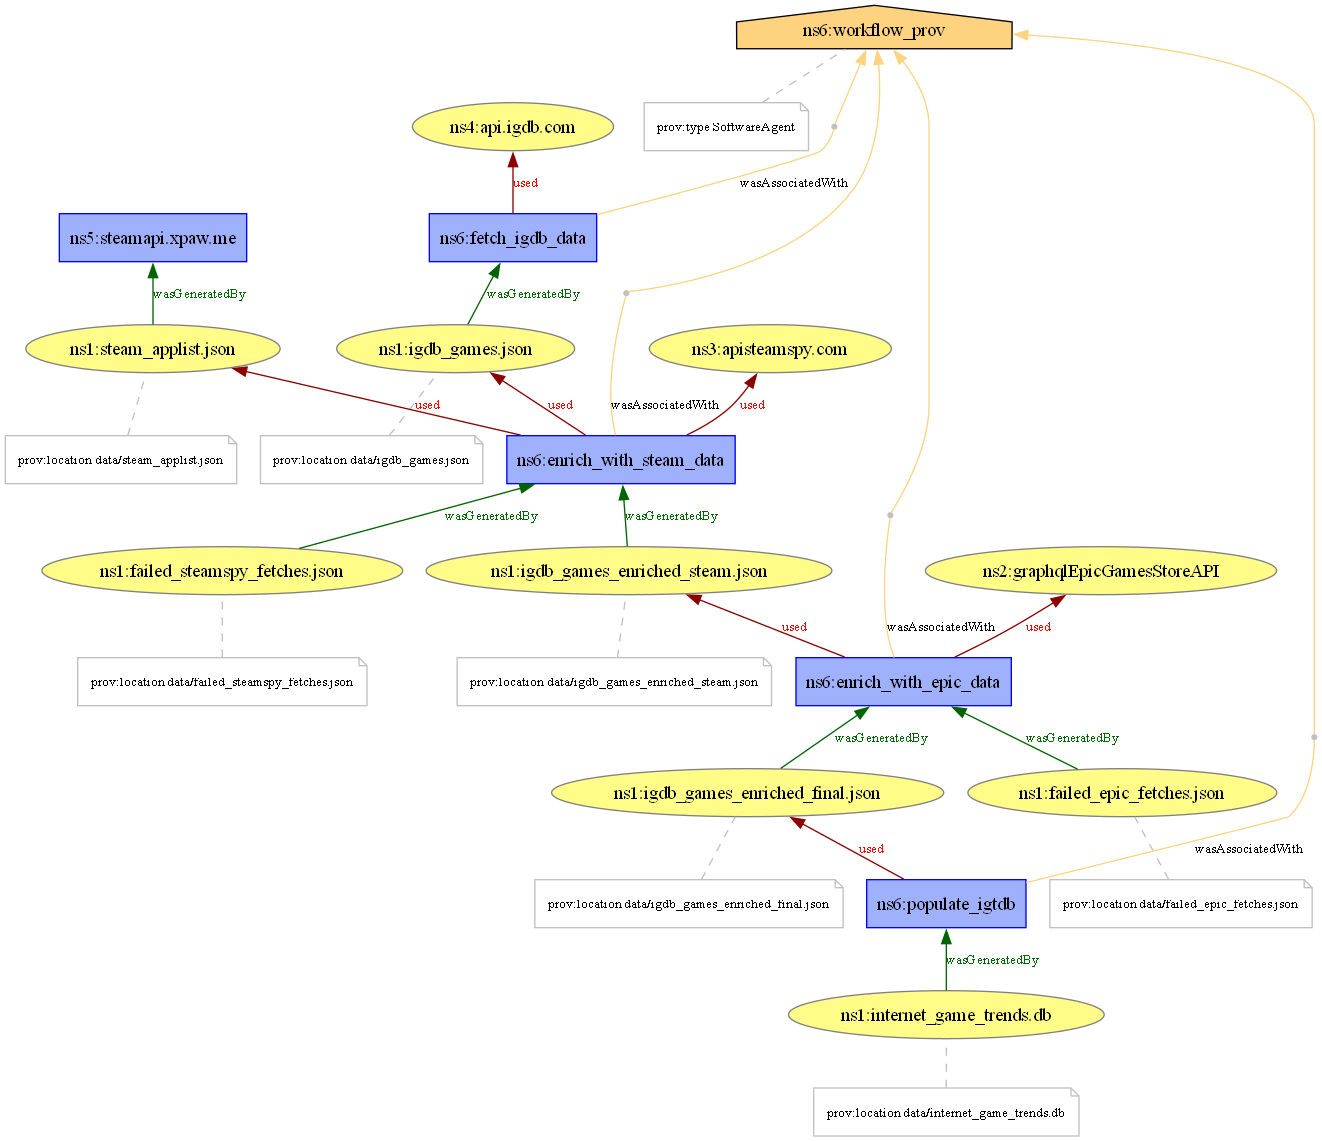

In [24]:
# Visualize provenance
doc = ProvDocument().deserialize("workflow_prov.nt", format="rdf", rdf_format="nt")
dot = prov_to_dot(doc)
display(Image(dot.create_png()))

**Save provenance graph**

Run the cell below to save the provenance graph:

In [27]:
pil_img = PILImage.new('RGB', (100, 50), color = 'red')
byte_stream = io.BytesIO()
pil_img.save(byte_stream, format='PNG')
image_data = byte_stream.getvalue()

displayed_image = Image(dot.create_png())

with open("workflow_prov_graph.png", "wb") as f:
    f.write(displayed_image.data)